**Distributions**

In [1]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

Downloaded thinkstats.py


In [2]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from thinkstats import decorate

**Frequency Tables**

In [4]:
from empiricaldist import FreqTab

In [5]:
t = [1.0, 2.0, 2.0, 3.0, 5.0]

In [6]:
ftab = FreqTab.from_seq(t)
ftab

,
1.0,1
2.0,2
3.0,1
5.0,1


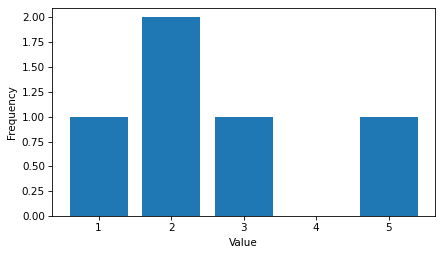

In [7]:
ftab.bar()
decorate(xlabel="Value", ylabel="Frequency")

In [8]:
ftab[5.0]

np.int64(1)

In [9]:
ftab(4)

0

In [10]:
ftab.qs

array([1., 2., 3., 5.])

In [11]:
ftab.fs

array([1, 2, 1, 1])

In [12]:
for x, freq in ftab.items():
  print(x, freq)

1.0 1
2.0 2
3.0 1
5.0 1


**NSFG Distributions**

In [13]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [14]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

Downloaded nsfg.py
Downloaded 2002FemPreg.dct
Downloaded 2002FemPreg.dat.gz


In [15]:
from nsfg import read_fem_preg

preg = read_fem_preg()

In [16]:
live = preg.query("outcome == 1")

In [17]:
ftab_lb = FreqTab.from_seq(live["birthwgt_lb"], name="birthwgt_lb")

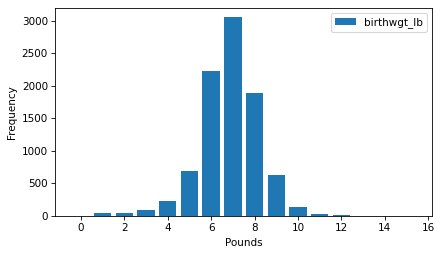

In [18]:
ftab_lb.bar()
decorate(xlabel="Pounds", ylabel="Frequency")

In [19]:
ftab_lb.idxmax()

np.float64(7.0)

In [20]:
ftab_lb.mode()

np.float64(7.0)

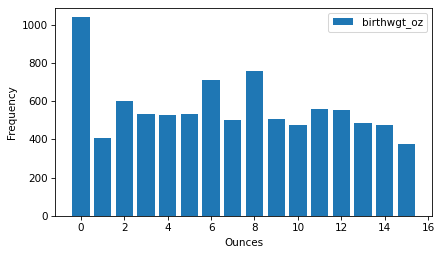

In [21]:
ftab_oz = (FreqTab.from_seq(live["birthwgt_oz"], name="birthwgt_oz"))
ftab_oz.bar()
decorate(xlabel="Ounces", ylabel="Frequency")

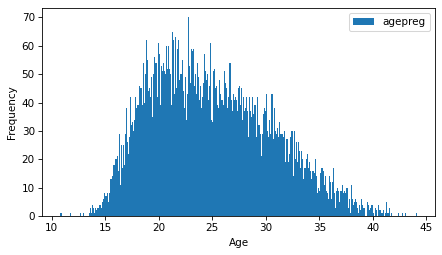

In [22]:
ftab_age = FreqTab.from_seq(live["agepreg"], name="agepreg")
ftab_age.bar(width=0.1)
decorate(xlabel="Age", ylabel="Frequency")

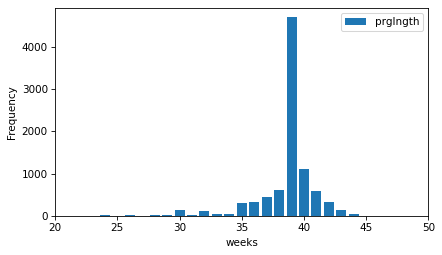

In [23]:
ftab_length = FreqTab.from_seq(live["prglngth"], name="prglngth")
ftab_length.bar()
decorate(xlabel="weeks", ylabel="Frequency", xlim=[20, 50])

**Outliers**

In [25]:
def smallest(ftab, n=10):
  return ftab[:n]

In [26]:
smallest(ftab_length)

,prglngth
prglngth,
0,1
4,1
9,1
13,1
17,2
18,1
19,1
20,1
21,2


In [29]:
def largest(ftab, n=10):
  return ftab[-n:]

In [30]:
largest(ftab_length)

,prglngth
prglngth,
40,1116
41,587
42,328
43,148
44,46
45,10
46,1
47,1
48,7


**First Babies**

In [31]:
firsts = live.query("birthord == 1")
others = live.query("birthord != 1")

In [32]:
ftab_first = FreqTab.from_seq(firsts["prglngth"], name="firsts")
ftab_other = FreqTab.from_seq(others["prglngth"], name="others")

In [33]:
def two_bar_plots(ftab1, ftab2, width=0.45):
  ftab1.bar(align="edge", width=-width)
  ftab2.bar(align="edge", width=width, alpha=0.5)

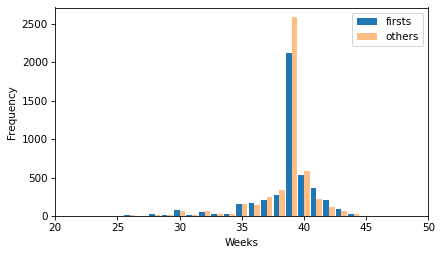

In [34]:
two_bar_plots(ftab_first, ftab_other)
decorate(xlabel="Weeks", ylabel="Frequency", xlim=[20, 50])

In [35]:
firsts["prglngth"].count(), others["prglngth"].count()

(np.int64(4413), np.int64(4735))

In [38]:
first_mean = firsts["prglngth"].mean()
other_mean = others["prglngth"].mean()
first_mean, other_mean

(np.float64(38.60095173351461), np.float64(38.52291446673706))

In [39]:
diff = first_mean - other_mean
diff, diff * 7 * 24

(np.float64(0.07803726677754952), np.float64(13.11026081862832))

**Effect Size**

In [40]:
diff / live["prglngth"].mean() * 100

np.float64(0.20237586646738304)

In [41]:
diff / live["prglngth"].std()

np.float64(0.028877623375210333)

In [43]:
group1, group2 = firsts["prglngth"], others["prglngth"]

In [45]:
v1, v2 = group1.var(), group2.var()

In [46]:
n1, n2 = group1.count(), group2.count()
pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)

In [47]:
np.sqrt(pooled_var)

np.float64(2.702210814495382)

In [48]:
firsts["prglngth"].std(), others["prglngth"].std()

(2.7919014146686947, 2.615852350439255)

In [49]:
def cohen_effect_size(group1, group2):
    diff = group1.mean() - group2.mean()

    v1, v2 = group1.var(), group2.var()
    n1, n2 = group1.count(), group2.count()
    pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)

    return diff / np.sqrt(pooled_var)

In [50]:
cohen_effect_size(firsts["prglngth"], others["prglngth"])

np.float64(0.028879044654449883)

In [51]:
cohen_effect_size(firsts["prglngth"], others["prglngth"])

np.float64(0.028879044654449883)